In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df = df.iloc[:, 1:]

In [5]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
encoder = LabelEncoder()

In [10]:
df['Species'] = encoder.fit_transform(df['Species'])

In [11]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]

In [13]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

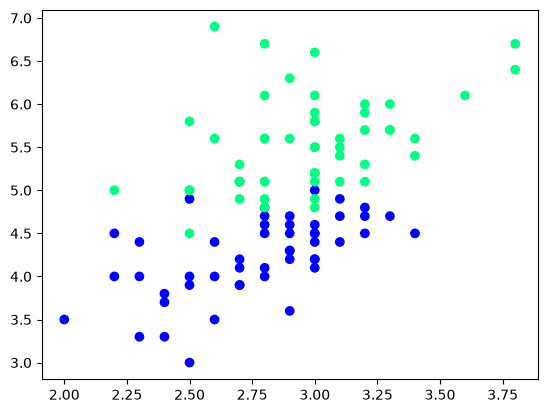

In [16]:
plt.scatter(df['SepalWidthCm'], df['PetalLengthCm'], c=df['Species'], cmap='winter')
plt.show()

In [17]:
df.shape

(100, 3)

In [18]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60, :].sample(10)
df_val = df.iloc[60:80, :].sample(5)
df_test = df.iloc[80:, :].sample(5)

In [19]:
df_train

,SepalWidthCm,PetalLengthCm,Species
92,2.6,4.0,1
94,2.7,4.2,1
93,2.3,3.3,1
87,2.3,4.4,1
133,2.8,5.1,2
125,3.2,6.0,2
73,2.8,4.7,1
112,3.0,5.5,2
67,2.7,4.1,1
123,2.7,4.9,2


In [20]:
df_val

,SepalWidthCm,PetalLengthCm,Species
53,2.3,4.0,1
108,2.5,5.8,2
132,2.8,5.6,2
118,2.6,6.9,2
146,2.5,5.0,2


In [21]:
df_test

,SepalWidthCm,PetalLengthCm,Species
113,2.5,5.0,2
143,3.2,5.9,2
141,3.1,5.1,2
104,3.0,5.8,2
144,3.3,5.7,2


In [23]:
X_test = df_val.iloc[:, 0:2].values
y_test = df_val.iloc[:, -1].values

## Case-1 Bagging

In [36]:
# Data for Tree 1
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2]
y = df.iloc[:, -1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
87,2.3,4.4,1
93,2.3,3.3,1
133,2.8,5.1,2
93,2.3,3.3,1
67,2.7,4.1,1
93,2.3,3.3,1
67,2.7,4.1,1
67,2.7,4.1,1


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

In [34]:
dt_bag1 = DecisionTreeClassifier()

In [35]:
evaluate(dt_bag1, X, Y)

ValueError: Number of labels=100 does not match number of samples=8

In [33]:
def evaluate(clf, X, y):
    clf.fit(X, y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test, y_pred))